# Network Statistics

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from common import *
from typing import List, Optional
from experiment import NetworkSetting
from data.http import HTTPExperiment
from data.media import MediaExperiment
from treatments.picoquic import treatment_map as http_treatment_map
from treatments.media import treatment_map as media_treatment_map

## Parse data

In [2]:
# HTTP benchmark
http_labels = [
    'picoquic',
    'picoquic_split',
    'picoquic_sidekick_0ms',
    'picoquic_sidekick_30ms',
    'picoquic_sidekick_60ms',
    # 'picoquic_sidekick_60ms_hint',
    'picoquic_iblt_0ms',
    'picoquic_iblt_30ms',
    'picoquic_iblt_60ms',
    # 'picoquic_iblt_60ms_hint',
]
treatments = [http_treatment_map[label] for label in http_labels]
network_setting = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=4, loss2=0)
data_size = 125000 * 20 * 10 # 125000 * bottleneck_bw * time_s
exp = HTTPExperiment(num_trials=1, treatments=treatments, network_settings=[network_setting], data_size=data_size)
http_raw_data = exp.to_raw_data(execute=False)

# Create plottable data
http_data = {}
for label in http_labels:
    outputs = http_raw_data.data[label][network_setting.label()][data_size]
    outputs = filter(lambda output: output.get('success'), outputs)
    outputs = list(map(lambda output: output['statistics'], outputs))
    http_data[label] = outputs[0]

In [3]:
# Media benchmark
media_labels = [
    'baseline',
    # 'psum_delay0',
    'psum_delay45',
    # 'psum_delay90',
    # 'psum_delay45_hint',
    # 'psum_delay45_nack',
    # 'psum_delay45_hint_nack',
    # 'iblt_delay0',
    # 'iblt_delay45',
    # 'iblt_delay90',
    # 'iblt_delay45_hint',
    # 'iblt_delay45_nack',
    # 'iblt_delay45_hint_nack'
]
duration = 180
treatments = [media_treatment_map[label] for label in media_labels]
network_setting = NetworkSetting(bw1=100, bw2=10, delay1=1, delay2=25, loss1=4, loss2=0)
exp = MediaExperiment(duration, treatments, network_setting)
media_raw_data = exp.to_raw_data(execute=False)

# Create plottable data
media_data = {}
for label in media_labels:
    output = media_raw_data.data[label]
    assert output.get('success')
    media_data[label] = output['statistics']

## Plotting Functions

In [4]:
def plot_network_statistics(data, labels: List[str], metric: str, title: str, pdf: Optional[str]=None):
    # Parse the universal set of ifaces
    ifaces = [value['ifaces'] for value in data.values()]
    for maybe_ifaces in ifaces:
        assert maybe_ifaces == ifaces[0]
    ifaces = ifaces[0]
    
    # Example data
    x = np.arange(len(ifaces))  # the label locations
    width = 1.0 / (len(labels) + 1)  # the width of the bars

    # Create plot
    fig, ax = plt.subplots()
    for i, label in enumerate(labels):
        values = data[label][metric]
        ax.bar(x + width * (i - len(labels) / 2 + 0.5), values, width, label=label)
    
    # Add labels, title, legend
    ax.set_ylabel(metric)
    ax.set_title(f'{title} ({metric})')
    ax.set_xticks(x)
    ax.set_xticklabels(ifaces)
    ax.legend()
    
    # Show plot
    plt.tight_layout()
    if pdf:
        save_pdf(pdf)
    plt.show()

## Plot Data

../figures/network_stats_http_tx_packets.pdf


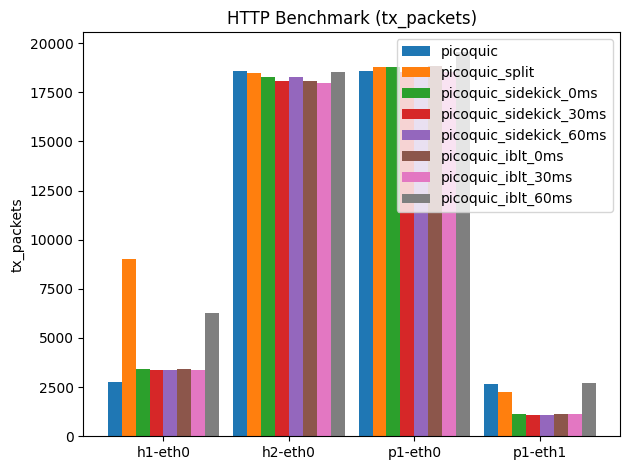

../figures/network_stats_http_tx_bytes.pdf


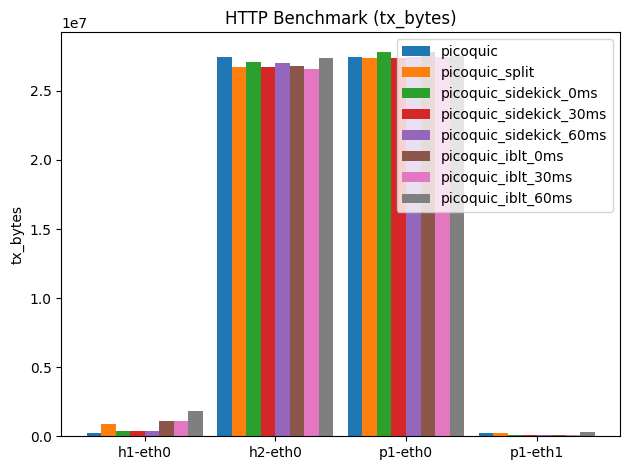

In [5]:
plot_network_statistics(http_data, http_labels, 'tx_packets', 'HTTP Benchmark', pdf='../figures/network_stats_http_tx_packets.pdf')
plot_network_statistics(http_data, http_labels, 'tx_bytes', 'HTTP Benchmark', pdf='../figures/network_stats_http_tx_bytes.pdf')

../figures/network_stats_media_tx_packets.pdf


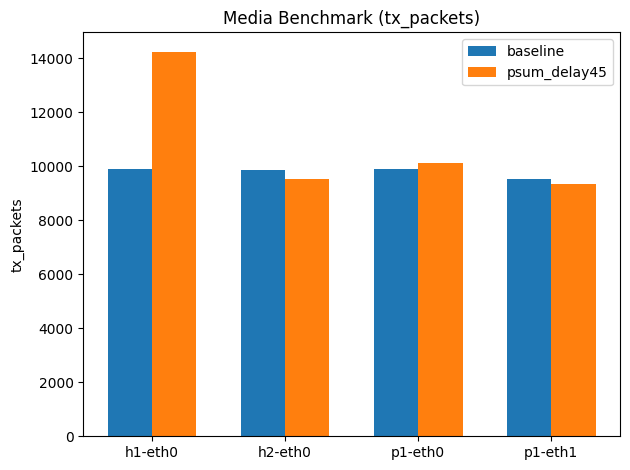

../figures/network_stats_media_tx_bytes.pdf


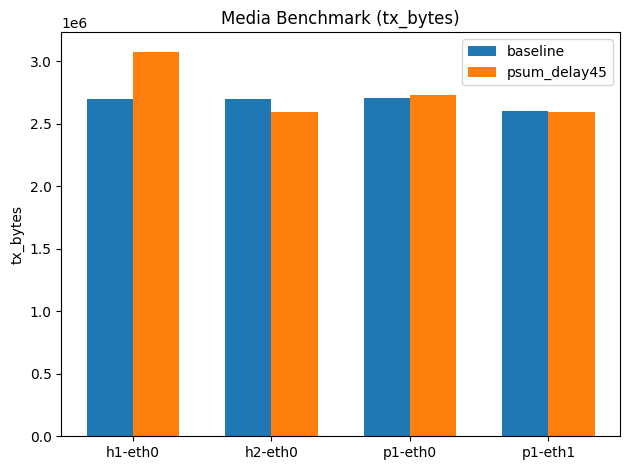

In [6]:
plot_network_statistics(media_data, media_labels, 'tx_packets', 'Media Benchmark', pdf='../figures/network_stats_media_tx_packets.pdf')
plot_network_statistics(media_data, media_labels, 'tx_bytes', 'Media Benchmark', pdf='../figures/network_stats_media_tx_bytes.pdf')